In [349]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.total_variation import total_variation
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd
from collections import Counter

from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import community as community_louvain
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from itertools import chain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


# load distribution

In [351]:
style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [ ]:

root_path = get_path("data")
tasic_purple_enm= np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_tasic_purple.npy"))
smart_purple_enm= np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_smart_purple.npy"))
x10_purple_enm= np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_10x_purple_10k.npy"))

In [356]:
dist_tasic_purple = load_dict(os.path.join(root_path,"final_dist_bottleneck_max", "dist_tasic_purple.pkl"))
dist_smart_purple = load_dict(os.path.join(root_path,"final_dist_bottleneck_max", "dist_smart_purple.pkl"))
dist_10x_purple = load_dict(os.path.join(root_path,"final_dist_bottleneck_max", "dist_10x_purple.pkl"))


In [ ]:
print(len(dist_tasic_purple["idx"]))
print(len(dist_smart_purple["idx"]))
print(len(dist_10x_purple["idx"]))

14
35
14


In [ ]:
print(dist_tasic_purple["density"].shape)
print(dist_smart_purple["density"].shape)
print(dist_10x_purple["density"].shape)

(14, 53)
(35, 53)
(14, 53)


In [ ]:
data_tri = [f"{i}" for i, dataset in enumerate([dist_tasic_purple["idx"], dist_smart_purple["idx"], dist_10x_purple["idx"]]) for j in dataset]
idx_tri = [f"{j}" for i, dataset in enumerate([dist_tasic_purple["idx"], dist_smart_purple["idx"], dist_10x_purple["idx"]]) for j in dataset]

In [ ]:
density_tri = np.vstack([dist_tasic_purple["density"], dist_smart_purple["density"], dist_10x_purple["density"]])

In [363]:
def total_variation_matrix(reshaped_array1, reshaped_array2):
    size = reshaped_array1.shape[0]
    result = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            result[i][j] = total_variation(reshaped_array1[i,:], reshaped_array2[j,:])
    return result

In [ ]:
def total_variation(dist_1, dist_2):
    return 0.5 * np.sum(np.abs(dist_1 - dist_2))

# tri purple

In [368]:
tri_mat = total_variation_matrix(density_tri, density_tri)

In [369]:
def complete_linkage_tri(threshold = 0.8):
    link = linkage(squareform(tri_mat), method='complete')
    clusters = fcluster(link, t=threshold, criterion='distance')
    # row_dendr = dendrogram(link)
    
    untrim_list_of_communities = [[] for _ in range(max(clusters))]
    untrim_idx = [[] for _ in range(max(clusters))]
    untrim_data = [[] for _ in range(max(clusters))]
    for i, cluster in enumerate(clusters):
        untrim_list_of_communities[cluster-1].append(i)    
        untrim_data[cluster-1].append(data_tri[i])
        untrim_idx[cluster-1].append(idx_tri[i])
    
    trim_list_of_communities = []
    trim_data = []
    trim_idx = []
    waste = []
    waste_data = []
    waste_idx = []
    for data, idx, lst in zip(untrim_data, untrim_idx, untrim_list_of_communities):
        if len(set(data)) == 3:
            trim_list_of_communities.append(lst)
            trim_data.append(data)
            trim_idx.append(idx)
        else:
            waste.append(lst)
            waste_data.append(data)
            waste_idx.append(idx)
    trim_list_of_communities.append(waste)
    trim_data.append(waste_data)
    trim_idx.append(waste_idx)
    
    return  trim_list_of_communities, trim_data, trim_idx

In [370]:
trim_list_of_communities, trim_data, trim_idx  = complete_linkage_tri(threshold = 0.75)

In [371]:
def tune_tri_threshold(lower_b = 0.5, higher_b = 1.0):
    ts = np.arange(lower_b, higher_b, 0.01)
    ave_tv = np.zeros((ts.shape))
    n_tv = np.zeros((ts.shape))    
    
    for i, t in enumerate(ts):
        trim_list_of_communities, trim_data, trim_idx  = complete_linkage_tri(threshold = t)
        tvs = []
        for idx, l in zip(trim_idx[:-1], trim_list_of_communities[:-1]):
            rows, cols = np.meshgrid(l, l)
            upper_idx = np.triu_indices(len(l), k=1)
            upper_lst = tri_mat[rows, cols][upper_idx].tolist()
            
            tvs = tvs + [np.mean(upper_lst)]
        ave_tv[i] = np.mean(np.array(tvs))
        n_tv[i] = len(tvs)
    return tri_mat, ave_tv, n_tv

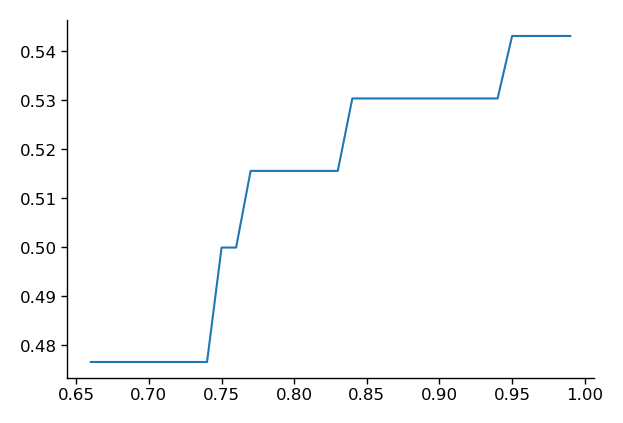

In [ ]:
plt.figure(figsize = (3,2))
plt.plot(np.arange(0.5, 1, 0.01), ave_tv)


In [ ]:
tri_mat, ave_tv, n_tv =tune_tri_threshold()

In [ ]:
print(trim_data)

[['0', '0', '0', '1', '1', '1', '1', '1', '1', '1', '1', '2', '2', '2', '2'], ['0', '1', '1', '1', '1', '2', '2'], [['0', '0', '0', '0', '0', '0', '1', '1', '1'], ['1', '1', '1', '1'], ['1', '1', '2', '2', '2', '2', '2', '2', '2'], ['1', '2'], ['1'], ['1', '1', '1'], ['0', '0', '0', '1', '1', '1'], ['1'], ['1', '1'], ['1', '1'], ['0', '1']]]


In [ ]:
print(trim_idx)

[['03', '11', '21', '00', '03', '13', '21', '31', '40', '43', '52', '00', '10', '21', '40'], ['12', '11', '15', '41', '46', '12', '42'], [['00', '10', '20', '30', '40', '50', '10', '17', '18'], ['02', '22', '42', '51'], ['20', '30', '01', '11', '20', '30', '31', '41', '51'], ['44', '50'], ['19'], ['50', '53', '56'], ['01', '02', '13', '16', '57', '58'], ['55'], ['01', '45'], ['12', '14'], ['14', '54']]]


In [ ]:
def pic_tri_pigeonhole_loops(trim_list_of_communities, trim_data, trim_idx, dataset_tasic, dataset_yao, dataset_10x, cell_group, groupable = True, save = False):
    if groupable == True:
        rows = len(trim_data)-1
        columns = np.max([len(l) for l in trim_data[:-1]])
        trim_list_of_communities = trim_list_of_communities[:-1]
        group_label = "groupable"
    else:
        rows = len(trim_data[-1])
        columns = np.max([len(l) for l in trim_data[-1]])
        trim_list_of_communities = trim_list_of_communities[-1]
        trim_idx = trim_idx[-1]
        trim_data = trim_data[-1]
        group_label = "ungroupable"
        
    fig, ax = plt.subplots(rows, columns, figsize=(columns, rows), constrained_layout=True)
    
    distances = {
        # "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res_tasic = load_multiple_res(datasets=dataset_tasic, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_tasic = {key: value for distance in all_res_tasic.values() for key, value in distance.items()}
    all_res_yao = load_multiple_res(datasets=dataset_yao, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_yao = {key: value for distance in all_res_yao.values() for key, value in distance.items()}
    all_res_10x = load_multiple_res(datasets=dataset_10x, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)
    new_all_res_10x = {key: value for distance in all_res_10x.values() for key, value in distance.items()}
    
    
    plot_loops = True
    tab10 = matplotlib.colormaps.get_cmap("tab10")
    existing_colors = [tab10(1)]
    colors = glasbey.extend_palette(existing_colors, columns+len(existing_colors)+5)[len(existing_colors)+1:]
    for i, lst in enumerate(trim_list_of_communities):
        for j, item in enumerate(lst):
            data_set = int(trim_data[i][j])
            dist = int(trim_idx[i][j][0])
            idx = int(trim_idx[i][j][1])
            # print(idx)
            cax = ax[i][j]
            cax.set_title(trim_idx[i][j], fontsize=7)
            if data_set == 0:
                res = new_all_res_tasic[list(new_all_res_tasic.keys())[dist]]
                if cell_group == "orange":
                    embd_n_mask = tasic_orange_enm
                elif cell_group == "purple":
                    embd_n_mask = tasic_purple_enm                    
            elif data_set == 1:
                res = new_all_res_yao[list(new_all_res_tasic.keys())[dist]]
                if cell_group == "orange":
                    embd_n_mask =  smart_orange_enm
                    cax.set_xlim(-20, 40)
                    cax.set_ylim(5, 85)
                elif cell_group == "purple":
                    embd_n_mask =  smart_purple_enm
                    cax.set_xlim(20, 80)
                    cax.set_ylim(-70, 40)
            elif data_set == 2:
                res = new_all_res_10x[list(new_all_res_tasic.keys())[dist]]
                if cell_group == "orange":
                    embd_n_mask = x10_orange_enm
                    cax.set_xlim(-65, -15)
                    cax.set_ylim(25, 70)
                elif cell_group == "purple":
                    embd_n_mask = x10_purple_enm
                    # cax.set_xlim(-90, -40)
                    # cax.set_ylim(-30, 30)
            life_times_loops = get_life_times(res, dim=1)
            
            loop_idx_sorted = np.argsort(life_times_loops)[::-1][idx]
            
            plot_scatter(cax, embd_n_mask, y="k", s=1, alpha=1, scalebar=False)
            plot_edges_on_scatter(ax=cax,
                                edge_idx=res["cycles"][1][loop_idx_sorted],
                                x=embd_n_mask,
                                color=colors[idx+1],
                                linewidth=1)
    for axx in ax.flat:
        axx.axis('off')
    fig.suptitle(f"tasic + smart seq + 10x, {cell_group}, {group_label} loops", fontsize =5)       
    plt.show()
    if save is True:
        fig.savefig(os.path.join(get_path("figures"), f"tv_3_bottleneck_{cell_group}_{group_label}.png"), dpi=300)


Done with tasic_purple_lamp5 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_64_

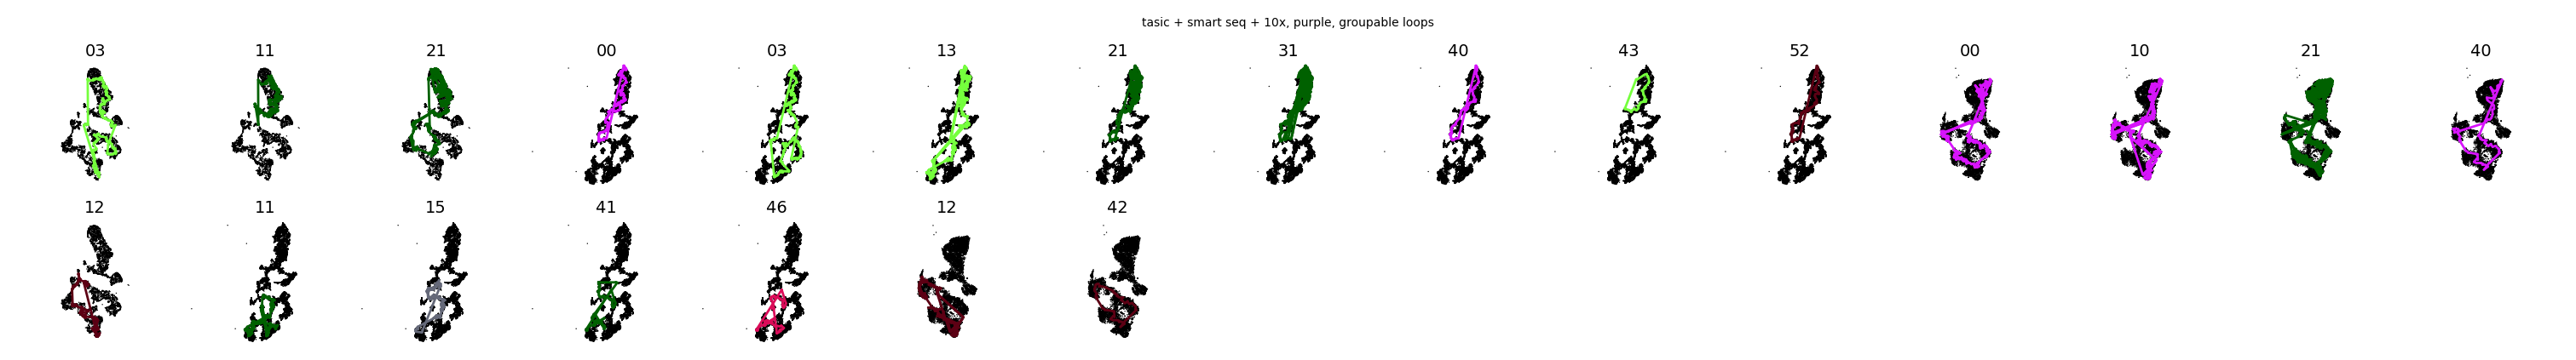

In [392]:
pic_tri_pigeonhole_loops(trim_list_of_communities, trim_data, trim_idx, "tasic_purple_lamp5", "yao_smart_purple", "yao_10x_male_purple_0_10k", "purple", save = True) #, saveas = "orange_fig_tri.png"

Done with tasic_purple_lamp5 None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_purple_lamp5 None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_purple None diffusion_k_15_t_64_

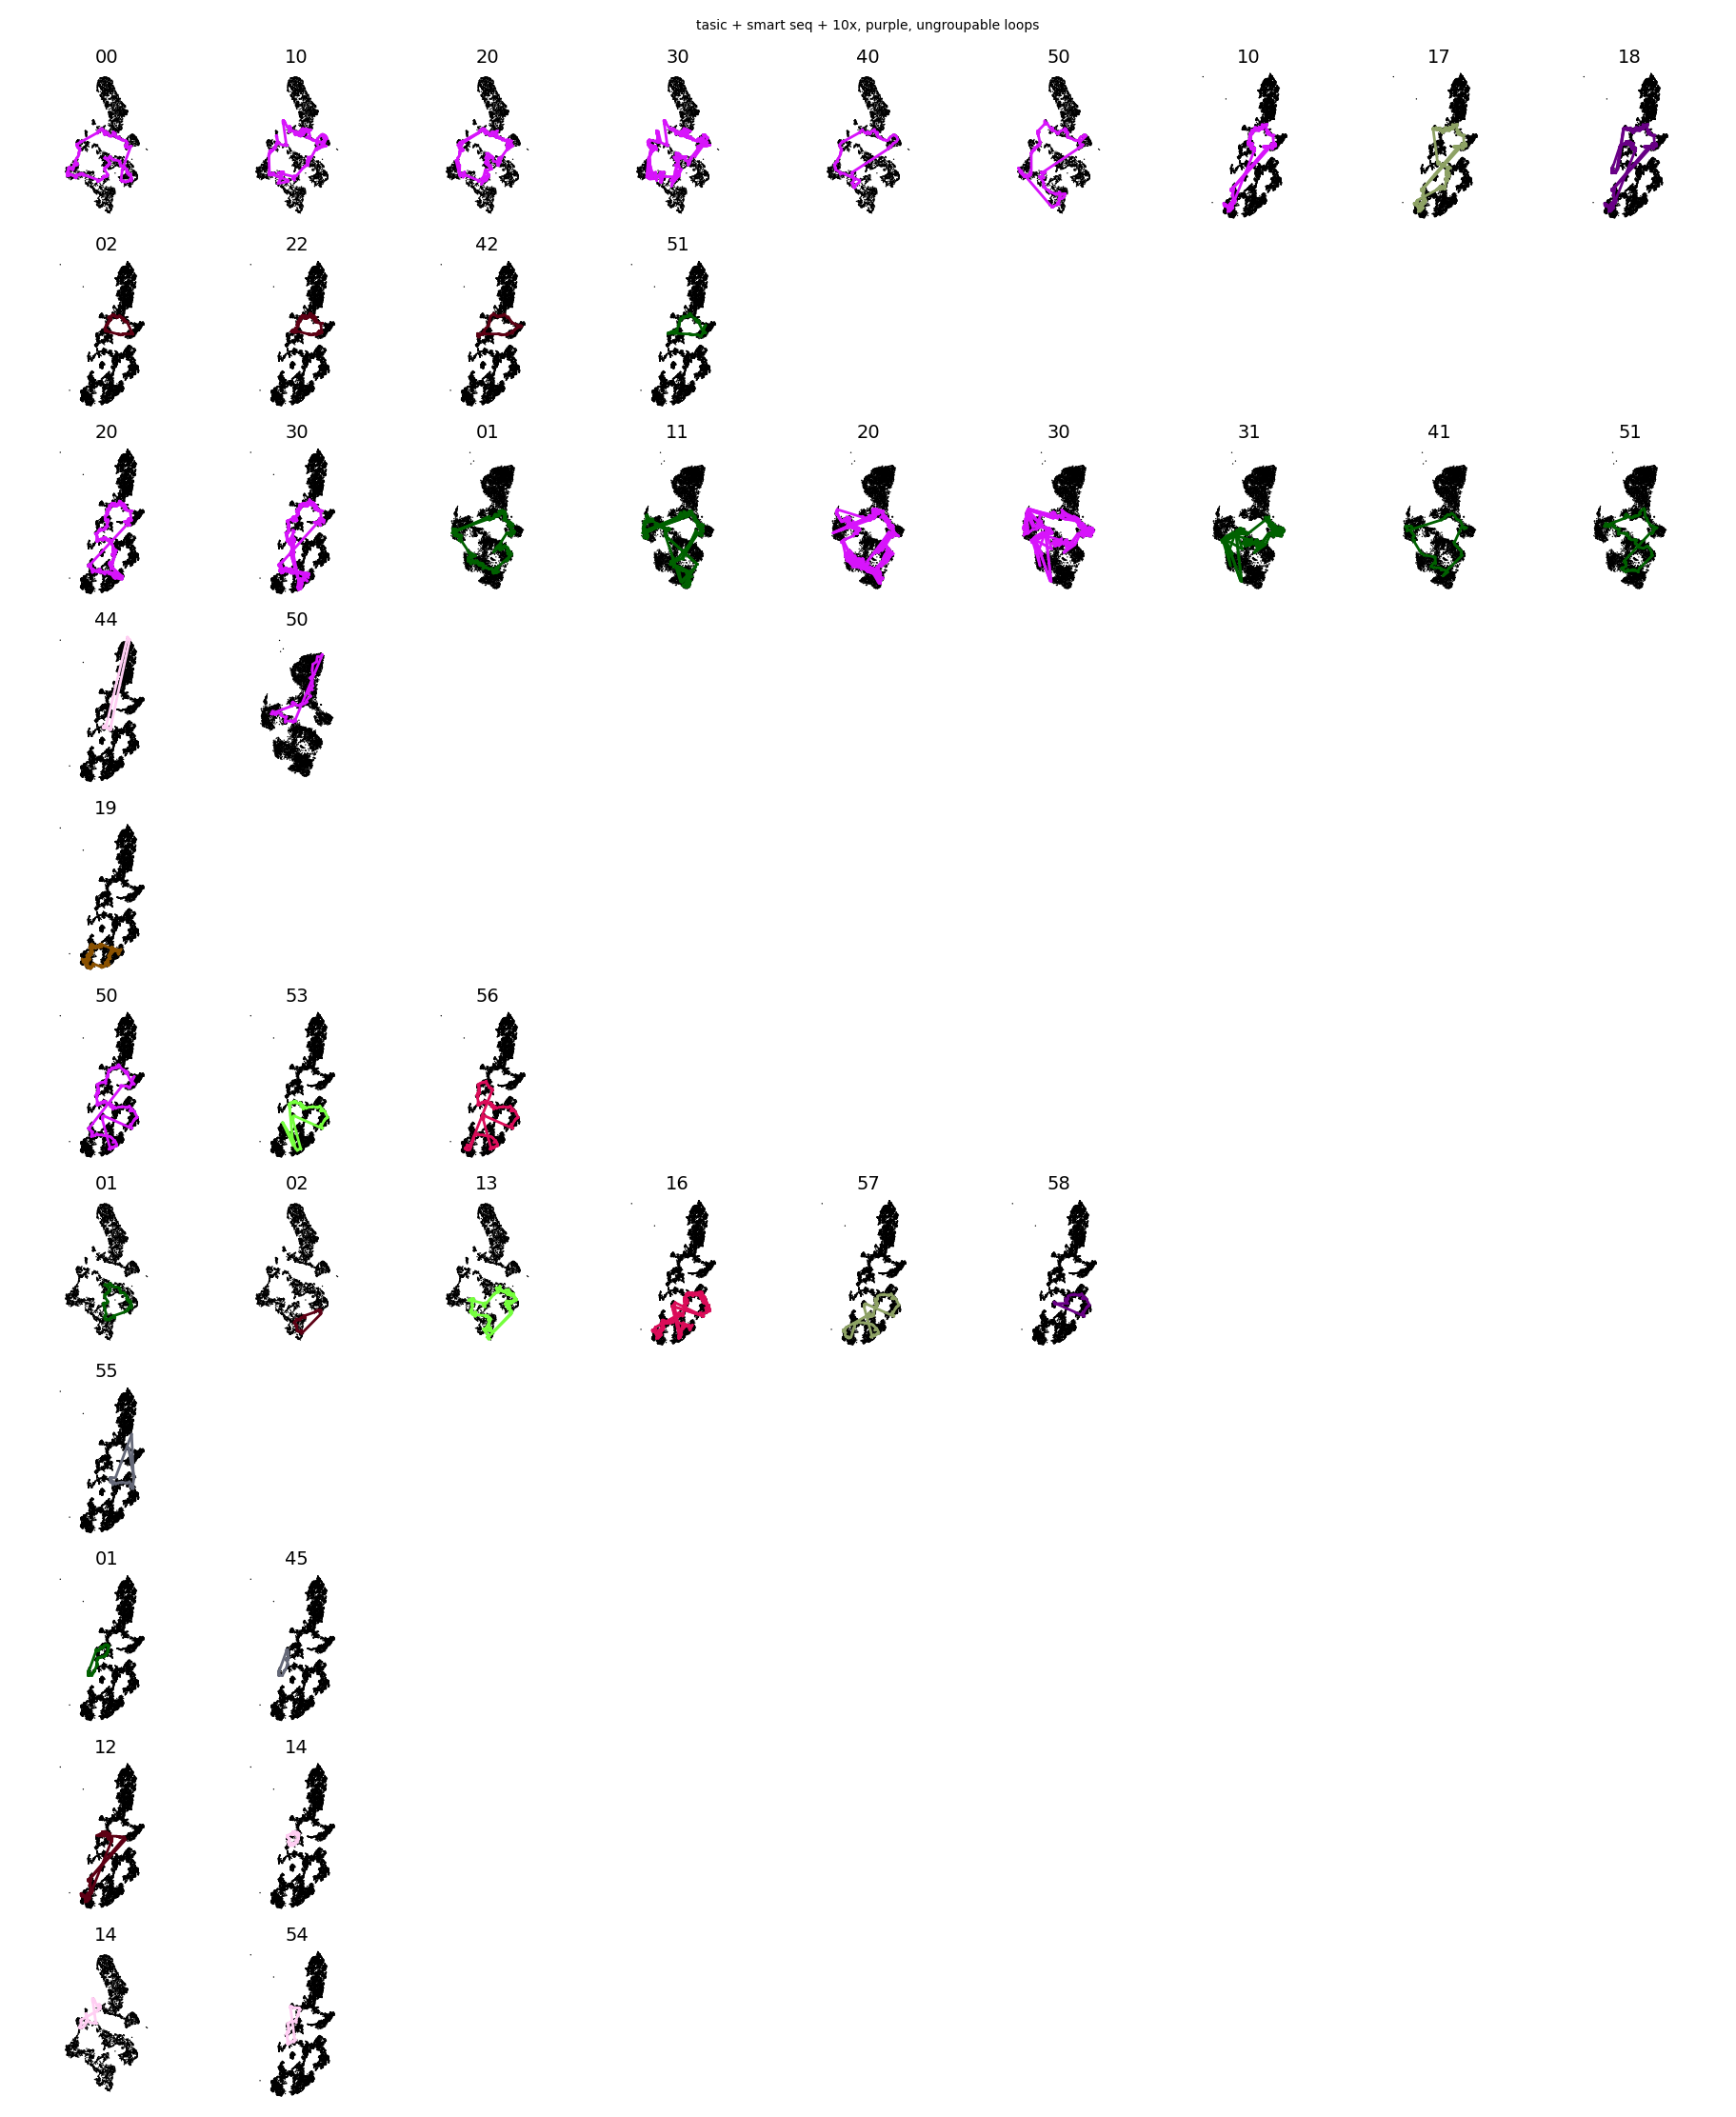

In [ ]:
pic_tri_pigeonhole_loops(trim_list_of_communities, trim_data, trim_idx, "tasic_purple_lamp5", "yao_smart_purple", "yao_10x_male_purple_0_10k", "purple", groupable = False, save = True) #, saveas = "orange_fig_tri.png"